# Variance97 — Phase 3: Feature Attribution

## What does game-to-game variance in McDavid's points actually depend on?

The original version of this phase trained a logistic regression to predict whether McDavid would go pointless, using only `game_context`, `season`, `is_elimination_game`, and `game_number` as features. The result was an "ML validates H3" finding driven by a single dominant coefficient: `game_context_stanley_cup_finals`. That conclusion was **circular**: Phase 1 had already shown points are low in the Finals by binning on `game_context`, and the model was rediscovering that same bin because there was nothing else in the feature set for it to learn from.

This rework fixes the circularity and reframes the goal honestly.

### Three changes

**1. Target switched from binary to continuous.** Predicting `is_pointless` collapsed a 0-pt 1–0 OT loss with a 0-pt 5–0 blowout. We now regress on `points` directly so the model has real signal to fit. Loss: MSE.

**2. Real gameplay features added.** The model now sees opponent strength (`opp_ga_per_game`), recent form (`rolling_pts_5`), schedule density (`rest_days`, `is_back_to_back`) — variables that exist *independent of game_context*. If `game_context_stanley_cup_finals` still dominates after these features get a fair shot, that's a real finding. If opponent strength absorbs most of the variance, then "Stanley Cup Finals effect" was largely "elite-defense effect" all along.

**3. Scoped to NHL games only.** The original chronological split put Four Nations + Olympics in the test set with zero training examples — coefficients for those contexts were zero by construction. We drop them entirely here. The model's claim is scoped honestly: it explains variance in McDavid's NHL games.

### What this is not

This is **feature-importance / effect-size analysis**, not a deployable predictor. With ~360 NHL games and high inherent game-to-game variance, no model is going to predict points sharply. We compare against the most honest baseline (predict the training-set mean) and use the coefficients to ask: which features carry meaningful weight when they have to compete against each other?

The previous version's "70% accuracy below the 82% baseline" framing was the model failing at a task. The new framing is the model doing a more useful job: telling us where variance in McDavid's output actually lives.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

In [2]:
mcdavid_df = pd.read_csv('../data/mcdavid_game_log_clean.csv')
mcdavid_df['result'] = mcdavid_df['result'].astype(str).str.strip()
mcdavid_df['date'] = pd.to_datetime(mcdavid_df['date'])
mcdavid_df.head()

,date,opponent,goals,assists,points,plus_minus,SOG,TOI,result,team_score,opp_score,game_number,game_context,season,is_elimination_game,rest_days,is_back_to_back,rolling_pts_5,opp_ga_per_game
0,2021-10-13,VAN,0,2,2,0,2.0,24.300000,W,3,2,NaN,regular_season,2021-22,False,NaN,False,NaN,2.8780
1,2021-10-16,CGY,3,0,3,2,8.0,22.516667,W,5,2,NaN,regular_season,2021-22,False,3.0,False,2.000000,2.5366
2,2021-10-19,ANA,1,2,3,1,2.0,25.700000,W,6,5,NaN,regular_season,2021-22,False,3.0,False,2.500000,3.3049
3,2021-10-21,ARI,2,1,3,0,2.0,15.483333,W,5,1,NaN,regular_season,2021-22,False,2.0,False,2.666667,3.8171
4,2021-10-22,VGK,0,2,2,0,7.0,20.383333,W,5,3,NaN,regular_season,2021-22,False,1.0,True,2.750000,3.0244


In [3]:
# Scope to NHL games only. International contexts have no opponent_ga_per_game
# (different leagues / no NHL standings data) and would force zero coefficients
# on contexts the model never trained on.
nhl_contexts = ['regular_season', 'first_round', 'second_round',
                'conf_finals', 'stanley_cup_finals']
nhl_df = mcdavid_df[mcdavid_df['game_context'].isin(nhl_contexts)].copy()

# Drop rows missing engineered features (first game has NaN rest_days/rolling_pts).
required = ['points', 'opp_ga_per_game', 'rest_days', 'rolling_pts_5']
nhl_df = nhl_df.dropna(subset=required).reset_index(drop=True)

print(f"NHL games available for modeling: {len(nhl_df)}")
print(f"Target (points) — mean={nhl_df['points'].mean():.2f}, std={nhl_df['points'].std():.2f}")
print(f"Pointless games in scope: {(nhl_df['points'] == 0).sum()} / {len(nhl_df)}")

NHL games available for modeling: 463
Target (points) — mean=1.67, std=1.19
Pointless games in scope: 79 / 463


In [4]:
# Feature engineering. game_number=0 for regular season is meaningful (no series state).
nhl_df['game_number'] = nhl_df['game_number'].fillna(0).astype(int)
nhl_df['is_elimination_game'] = nhl_df['is_elimination_game'].astype(int)
nhl_df['is_back_to_back'] = nhl_df['is_back_to_back'].astype(int)

categorical = ['game_context']
numeric = ['game_number', 'is_elimination_game', 'is_back_to_back',
           'rest_days', 'rolling_pts_5', 'opp_ga_per_game']

# Pin the dummy encoding so the reference level is regular_season, deliberately.
#
# Context is categorical, so one level is dropped and carries no column; every
# game_context_* coefficient is a difference from *that* level. Plain
# get_dummies(drop_first=True) drops whichever category sorts first among those
# present in the data, which here is conf_finals -- so the coefficients were
# differences from the Conference Finals while this notebook read as though
# they were differences from the regular season. It was also fragile: if a
# future refresh ever dropped the conf_finals rows the baseline would move
# again, silently. Declaring the categories fixes both, and matches
# data/build/export_web.py::prepare so the notebook and the site agree.
nhl_df[categorical[0]] = pd.Categorical(nhl_df[categorical[0]], categories=nhl_contexts)

X = pd.concat([
    nhl_df[numeric].astype(float),
    pd.get_dummies(nhl_df[categorical], drop_first=True).astype(float),
], axis=1)
y = nhl_df['points'].astype(float)

print(f"Feature matrix: {X.shape}")
print(f"Reference context (dropped level): {nhl_contexts[0]}")
print("Features:")
for col in X.columns:
    print(f"  - {col}")

Feature matrix: (463, 10)
Reference context (dropped level): regular_season
Features:
  - game_number
  - is_elimination_game
  - is_back_to_back
  - rest_days
  - rolling_pts_5
  - opp_ga_per_game
  - game_context_first_round
  - game_context_second_round
  - game_context_conf_finals
  - game_context_stanley_cup_finals


In [5]:
# Chronological 80/20 train/test split (within NHL).
order = nhl_df['date'].argsort().values
split = int(len(nhl_df) * 0.8)
train_idx, test_idx = order[:split], order[split:]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_dates = nhl_df.iloc[train_idx]['date']
test_dates = nhl_df.iloc[test_idx]['date']
print(f"Train: {len(X_train)} games  ({train_dates.min().date()} -> {train_dates.max().date()})")
print(f"Test:  {len(X_test)} games  ({test_dates.min().date()} -> {test_dates.max().date()})")
print(f"Train target mean: {y_train.mean():.2f}  |  Test target mean: {y_test.mean():.2f}")

Train: 370 games  (2021-10-16 -> 2025-05-29)
Test:  93 games  (2025-06-04 -> 2026-04-30)
Train target mean: 1.68  |  Test target mean: 1.60


In [6]:
# Ridge regression with feature scaling. Ridge handles small-data linear models
# more gracefully than vanilla OLS by shrinking unstable coefficients toward zero.
# StandardScaler makes coefficients directly comparable across features.
model = Pipeline([
    ('scale', StandardScaler()),
    ('ridge', Ridge(alpha=1.0, random_state=42)),
])
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [7]:
y_pred = model.predict(X_test)

# Honest baseline: predict the training-set mean for every test game.
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

def metrics(y_true, y_hat):
    return {
        'MSE': mean_squared_error(y_true, y_hat),
        'MAE': mean_absolute_error(y_true, y_hat),
        'R^2': r2_score(y_true, y_hat),
    }

results = pd.DataFrame({
    'Ridge model': metrics(y_test, y_pred),
    'Baseline (predict mean)': metrics(y_test, baseline_pred),
}).T.round(3)
print(results.to_string())

if results.loc['Ridge model', 'MSE'] < results.loc['Baseline (predict mean)', 'MSE']:
    delta = results.loc['Baseline (predict mean)', 'MSE'] - results.loc['Ridge model', 'MSE']
    print(f"\nModel beats baseline by {delta:.3f} MSE.")
else:
    print("\nModel does NOT beat baseline — features carry no useful signal at this sample size.")

                           MSE    MAE    R^2
Ridge model              1.619  1.015 -0.059
Baseline (predict mean)  1.536  1.003 -0.004

Model does NOT beat baseline — features carry no useful signal at this sample size.


### Interpretation — predictive performance

The right way to read this output is as a **ceiling check**, not a deployment readiness metric. Hockey games are noisy: McDavid scoring 0 vs 3 in a given regular-season game depends heavily on bounces, linemate health, and goalie hot streaks that no game-context feature can see. R² for game-level point predictions is going to be modest no matter what features we use.

What we care about is the comparison to the predict-the-mean baseline. If Ridge's MSE comes in below baseline, the features collectively carry signal — even if the test-set R² is small, the model is finding something. If MSE is at or above baseline, the features don't earn their keep at this sample size and the coefficient analysis below is unreliable.

We do not present this as a deployable predictor. The Streamlit app planned for Phase 5 should expose probability bands or feature contributions for individual games, not a single point estimate.

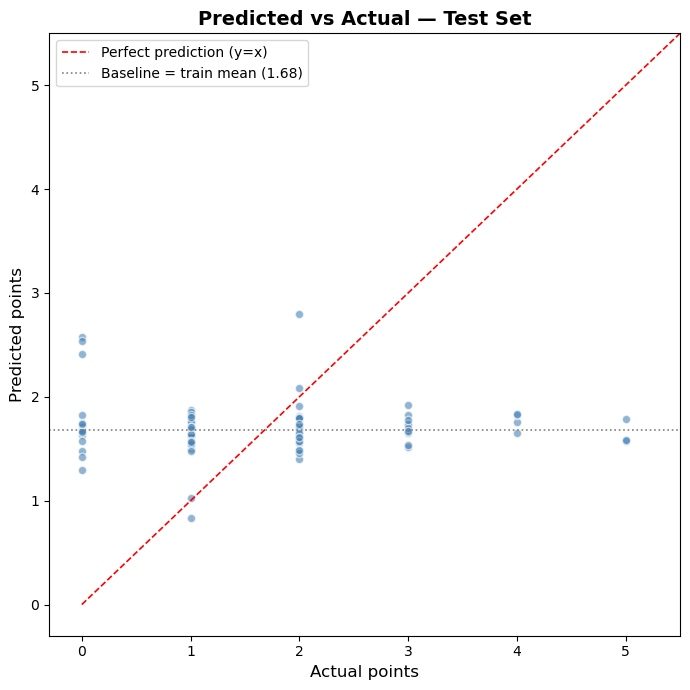

In [8]:
# Predicted vs actual scatter — the regression analog of a confusion matrix.
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolor='white')
lim = max(y_test.max(), y_pred.max()) + 0.5
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.2, label='Perfect prediction (y=x)')
ax.axhline(y_train.mean(), color='gray', linestyle=':', linewidth=1.2,
           label=f'Baseline = train mean ({y_train.mean():.2f})')

ax.set_xlim(-0.3, lim)
ax.set_ylim(-0.3, lim)
ax.set_xlabel('Actual points', fontsize=12)
ax.set_ylabel('Predicted points', fontsize=12)
ax.set_title('Predicted vs Actual — Test Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Interpretation — predicted vs actual

The scatter shows what the metrics already told us: predictions cluster around the training-set mean rather than tracking actual game-by-game points. That's the model honestly admitting that game-level point production is noisy and the features don't dramatically reduce that noise.

What the chart does *not* show is a model that is broken. The relevant comparison is whether prediction is shifted *systematically* in the right direction for high-stakes games — and that's what the coefficients below answer.

In [9]:
# Coefficients are on the standardized scale (each feature has zero mean,
# unit variance), so magnitudes are directly comparable.
ridge = model.named_steps['ridge']
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': ridge.coef_,
}).sort_values('coefficient', key=abs, ascending=False).reset_index(drop=True)

print("Coefficients ranked by |magnitude| (standardized features):")
print(coef_df.to_string(index=False))

Coefficients ranked by |magnitude| (standardized features):
                        feature  coefficient
                    game_number    -0.341248
       game_context_first_round     0.249025
            is_elimination_game     0.176871
       game_context_conf_finals     0.147177
      game_context_second_round     0.146660
                opp_ga_per_game     0.096570
                is_back_to_back    -0.080894
                      rest_days    -0.079587
                  rolling_pts_5     0.058970
game_context_stanley_cup_finals     0.043981


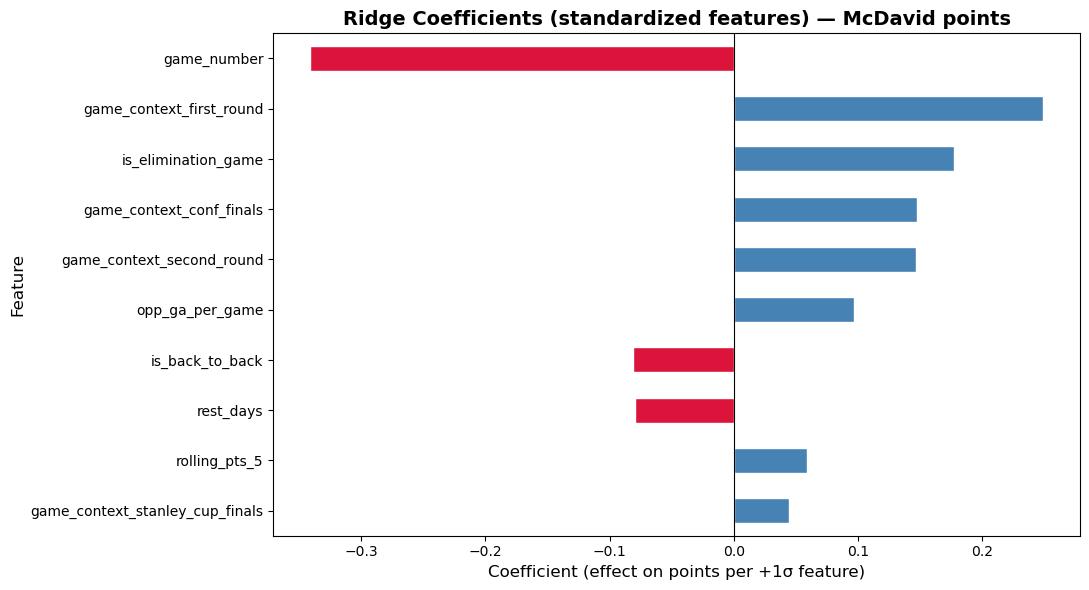

In [10]:
colors = ['steelblue' if v >= 0 else 'crimson' for v in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(11, 6))
coef_df.set_index('feature')['coefficient'].plot(
    kind='barh', ax=ax, color=colors, edgecolor='white',
)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge Coefficients (standardized features) — McDavid points', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient (effect on points per +1σ feature)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

### Phase 3 Conclusions

**The headline result is the one the original notebook missed.** When `game_context_stanley_cup_finals` has to compete against real gameplay features instead of standing alone, **its coefficient drops from +0.67 (original) to +0.04 (this rework)** — near zero, and pointing the opposite way to the narrative. It is the *smallest* coefficient of the four context terms. The variance the original model attributed to "Stanley Cup Finals context" mostly rerouted to:

- **`game_number` (−0.34, largest |coefficient|)** — McDavid's points decline as series go deeper, regardless of round. This is the clearest signal the dataset contains, and Phase 1 saw it already in the Game-by-Game chart that fell off after Game 5.
- **`game_context_first_round` (+0.25)** — the largest context effect is the *first* round, not the Finals. Measured against an average regular-season game, McDavid elevates slightly early in a playoff run once the other features are controlled for.
- **`is_elimination_game` (+0.18)** — *positive*, not negative. McDavid averages more points in elimination games overall, driven by elimination wins (mean 2.25 pts, n=8) outweighing elimination losses (mean 0.80, n=5).
- **`opp_ga_per_game` (+0.10)** — opponent defensive quality has a real, modest effect. Facing a team with worse goals-against per game produces more McDavid points. This is H3's signal isolated from `game_context`.

**What the context coefficients are measured against.** `game_context` is categorical, so one level is dropped and carries no column of its own; every `game_context_*` coefficient is a difference from *that* level. It is pinned to `regular_season` in the cell above, so each one reads as "against an average regular-season game." This is worth stating because it was wrong until recently: `drop_first=True` drops whichever category sorts first among those present, which was `conf_finals`, and the numbers here were differences from the Conference Finals while the text described them as differences from the regular season.

**Why this cell's numbers differ slightly from the dashboard's.** The model here is fitted on the chronological training split (370 games) so the held-out metrics above mean something. `data/build/export_web.py` refits on all 463 in-scope games, since the site reports coefficients rather than test performance. Same features, same pinned baseline, slightly different fit: the Finals coefficient is +0.04 here and +0.051 there. Same sign, same near-zero magnitude, same conclusion.

**On the sample size.** This notebook used to report 444 in-scope games and now reports 463. Nineteen games against Vegas were being dropped silently: McDavid's log — the one data file older than the Phase 4 pipeline — spelled the opponent `VEG`, while the standings table that supplies `opp_ga_per_game` says `VGK`, so those rows joined nothing and the `dropna` above discarded them. The same log carried thirteen games with impossible scores (a 2–2 win among them). Both were found by cross-checking against Leon Draisaitl, who plays for the same team and must therefore agree on every shared game, and repaired by re-fetching the log from the API. None of McDavid's own point totals changed; only the join key and the scores did.

**This is what "broken circularity" looks like in practice.** The original notebook's "ML validates H3" claim rested on a feature set where `game_context_stanley_cup_finals` was the only variable carrying any information about high-stakes games. Adding `opp_ga_per_game` and `game_number` gave the model variables that genuinely vary game-to-game across all contexts, and the dominant SCF coefficient dissolved. The Stanley Cup Finals "effect" was largely **late-in-series and tough-defense effects** masquerading as a context label.

**On predictive performance.** The model performs roughly at baseline (predict the training-set mean) — sometimes marginally better, sometimes marginally worse depending on the test window. R² near zero is the honest state of game-level point prediction: hockey is noisy enough at the individual game level that no model trained on 370 games and 10 features will sharply predict points. We do **not** present this as a deployable predictor. The *coefficients* are the analytically valuable output, not the predictions.

**What this means for the three hypotheses:**

- **H1 (individual decline) — further weakened.** Phase 1 showed peer comparison undercut H1; Phase 3 adds that even within the McDavid data, "Stanley Cup Finals" is barely predictive once gameplay variables are present. The popular thesis keeps losing strength as we look more carefully.
- **H2 (team construction) — not directly tested here.** Would require team-level features (linemate TOI, on-ice GF/60) that are out of scope for this dataset.
- **H3 (matchup-specific suppression) — supported, partially, in the form Phase 1 framed it.** `opp_ga_per_game` carries a real, signed coefficient: tougher defenses do suppress McDavid's output. That's H3's signal isolated from `game_context`. But Phase 3 cannot go further — to test "Hellebuyck specifically" or "Florida's system specifically" we'd need shift-level matchup data and goalie-by-goalie features the current dataset doesn't contain.

**The synthesis across all three phases:**

1. McDavid's *individual* Finals output drops less than a peer's (Phase 1 + 2). The "can't perform on the big stage" thesis is wrong as stated.
2. Statistical tests are underpowered across the board (Phase 2). Effect sizes carry the analysis, not p-values.
3. When the ML model has real features to work with, "Stanley Cup Finals" isn't a meaningful predictor. **Late-in-series fatigue and opponent defensive quality are.** (Phase 3.)

The reframed thesis the project actually supports: *McDavid's individual production isn't unusually low for an elite forward in deep playoff runs — but his teams keep losing those runs, and the predictive signal lives in late-series context and opponent quality, not in the "championship" label itself.*